<a href="https://colab.research.google.com/github/kirthiga2312/CodeAlpha_Credit_Scoring_Model/blob/main/Copy_of_untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Load the German Credit dataset
credit_data = fetch_ucirepo(id=144)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# See the data
X = credit_data.data.features
y = credit_data.data.targets

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   
2        A14          12        A34        A46        2096        A61   
3        A11          42        A32        A42        7882        A61   
4        A11          24        A33        A40        4870        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   
2        A74           2        A93        A101            3        A121   
3        A74           2        A93        A103            4        A122   
4        A73           3        A93        A101            4        A124   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           67

In [ ]:
print("Dataset shape:", X.shape)

print("\nNumber of rows:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nData types:")
print(X.dtypes)

Dataset shape: (1000, 20)

Number of rows: 1000
Number of features: 20

Data types:
Attribute1     object
Attribute2      int64
Attribute3     object
Attribute4     object
Attribute5      int64
Attribute6     object
Attribute7     object
Attribute8      int64
Attribute9     object
Attribute10    object
Attribute11     int64
Attribute12    object
Attribute13     int64
Attribute14    object
Attribute15    object
Attribute16     int64
Attribute17    object
Attribute18     int64
Attribute19    object
Attribute20    object
dtype: object


In [ ]:
print("Missing values in each column:")
print(X.isnull().sum())

Missing values in each column:
Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
Attribute6     0
Attribute7     0
Attribute8     0
Attribute9     0
Attribute10    0
Attribute11    0
Attribute12    0
Attribute13    0
Attribute14    0
Attribute15    0
Attribute16    0
Attribute17    0
Attribute18    0
Attribute19    0
Attribute20    0
dtype: int64


In [ ]:
# Find categorical columns

categorical_columns = X.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7',
       'Attribute9', 'Attribute10', 'Attribute12', 'Attribute14',
       'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_encoded = encoder.fit_transform(X)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

Original shape: (1000, 20)
Encoded shape: (1000, 1075)


In [ ]:
# Separate categorical and numerical columns

categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

print("Categorical columns:", len(categorical_columns))
print("Numerical columns:", len(numerical_columns))

Categorical columns: 13
Numerical columns: 7


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_categorical = encoder.fit_transform(X[categorical_columns])

X_numerical = X[numerical_columns].values

print("Categorical data shape:", X_categorical.shape)
print("Numerical data shape:", X_numerical.shape)

Categorical data shape: (1000, 54)
Numerical data shape: (1000, 7)


In [ ]:
import numpy as np

X_final = np.hstack([X_categorical, X_numerical])

print("Final data shape:", X_final.shape)

Final data shape: (1000, 61)


In [ ]:
# Convert target values from 1,2 to 0,1

y_final = y.iloc[:, 0].map({1: 0, 2: 1})

print("Target values:")
print(y_final.value_counts())

Target values:
class
0    700
1    300
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
     )
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 61)
Testing data: (200, 61)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Make predictions on test data

y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.775
Accuracy percentage: 77.5 %


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.6363636363636364
Recall: 0.5833333333333334
F1-Score: 0.6086956521739131


Confusion Matrix:
[[120  20]
 [ 25  35]]


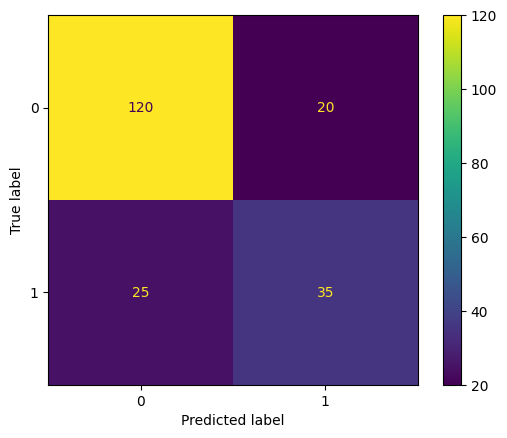

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7997619047619048


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)
tree_model.fit(X_train, y_train)
print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
# Make predictions using Decision Tree

tree_pred = tree_model.predict(X_test)

print("Decision Tree Predictions:")
print(tree_pred[:20])

Decision Tree Predictions:
[0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Accuracy percentage:", tree_accuracy * 100, "%")

Decision Tree Accuracy: 0.645
Decision Tree Accuracy percentage: 64.5 %


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)

tree_prob = tree_model.predict_proba(X_test)[:, 1]
tree_roc_auc = roc_auc_score(y_test, tree_prob)

print("Decision Tree Precision:", tree_precision)
print("Decision Tree Recall:", tree_recall)
print("Decision Tree F1-Score:", tree_f1)
print("Decision Tree ROC-AUC:", tree_roc_auc)

Decision Tree Precision: 0.417910447761194
Decision Tree Recall: 0.4666666666666667
Decision Tree F1-Score: 0.4409448818897638
Decision Tree ROC-AUC: 0.675952380952381


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# Make predictions using Random Forest

rf_pred = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred[:20])

Random Forest Predictions:
[0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy percentage:", rf_accuracy * 100, "%")

Random Forest Accuracy: 0.755
Random Forest Accuracy percentage: 75.5 %


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1-Score:", rf_f1)
print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest Precision: 0.6486486486486487
Random Forest Recall: 0.4
Random Forest F1-Score: 0.4948453608247423
Random Forest ROC-AUC: 0.7741666666666667


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        tree_recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        tree_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        tree_roc_auc,
        rf_roc_auc
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression     0.775   0.636364  0.583333  0.608696  0.799762
1        Decision Tree     0.645   0.417910  0.466667  0.440945  0.675952
2        Random Forest     0.755   0.648649  0.400000  0.494845  0.774167


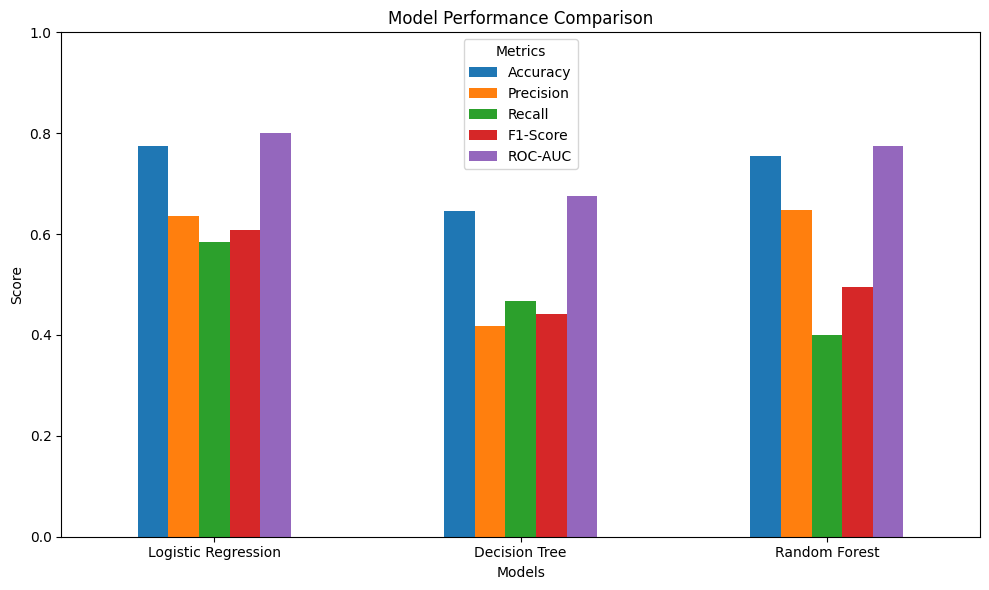

In [ ]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()